<a href="https://colab.research.google.com/github/abhishek18-blog/DataScience-and-ML/blob/main/A_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Dataset/Distances_of_indian_cities.csv')

print("First 5 rows of the CSV file:")
display(df.head())

First 5 rows of the CSV file:


,Unnamed: 0,Kolapur,Ahmedabad,Vellore,Agra,Cuttack,Guwahati,Kolkata,Aligarh,Madurai,...,Delhi,Gwalior,Solapur,Bangalore,Bikaner,Ghaziabad,Rajkot,Lucknow,Dwarka,Mumbai
0,Kolapur,100000.000,137.513,1454.366,737.237,1517.434,2045.019,1718.420,787.430,1690.350,...,762.516,706.893,769.650,1362.334,486.823,788.614,195.305,991.731,327.281,563.090
1,Ahmedabad,137.513,100000.000,1320.030,715.165,1403.936,1971.163,1620.624,775.508,1563.090,...,772.896,665.641,637.919,1231.355,558.213,796.692,199.104,943.527,380.411,452.822
2,Vellore,1454.366,1320.030,100000.000,1595.387,1121.923,1994.073,1467.862,1672.211,351.499,...,1763.191,1487.015,687.538,154.314,1785.731,1769.621,1364.952,1567.737,1491.432,947.486
3,Agra,737.237,715.165,1595.387,100000.000,1092.406,1371.776,1163.269,78.774,1919.719,...,180.843,108.641,1070.167,1572.254,472.531,179.075,906.589,292.669,1064.295,1054.728
4,Cuttack,1517.434,1403.936,1121.923,1092.406,100000.000,872.170,347.177,1136.081,1459.441,...,1261.993,1012.955,1152.092,1211.035,1523.690,1249.453,1575.895,867.006,1763.468,1377.594


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Kolapur,0
Ahmedabad,0
Vellore,0
Agra,0
Cuttack,0
Guwahati,0
Kolkata,0
Aligarh,0
Madurai,0


In [ ]:
import math
import heapq

# Easy heuristic: distance between two points (lat/lon)
def heuristic(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def a_star_search(graph, start, goal):
    # Priority queue for nodes to visit
    frontier = []
    heapq.heappush(frontier, (0, start))

    came_from = {start: None}
    cost_so_far = {start: 0}

    while frontier:
        current = heapq.heappop(frontier)[1]

        if current == goal:
            break

        for next_node in graph.get(current, []):
            new_cost = cost_so_far[current] + graph[current][next_node]
            if next_node not in cost_so_far or new_cost < cost_so_far[next_node]:
                cost_so_far[next_node] = new_cost
                priority = new_cost + heuristic(goal, next_node)
                heapq.heappush(frontier, (priority, next_node))
                came_from[next_node] = current

    return came_from, cost_so_far

print("A* Algorithm structure ready. You can now define your graph nodes using the latitude and longitude from your DataFrame.")

A* Algorithm structure ready. You can now define your graph nodes using the latitude and longitude from your DataFrame.


In [ ]:
import pandas as pd
import math
import heapq
import folium # Added folium import for visualization

graph = {}
cities = df_distances.index.tolist()

for city1 in cities:
    graph[city1] = {}
    for city2 in cities:
        if city1 != city2:
            distance = df_distances.loc[city1, city2]
            if pd.notna(distance): # Only add connection if distance is not NaN
                graph[city1][city2] = distance

# Redefine the heuristic function for the A* algorithm.
# Since we only have distances and no coordinates, we'll use a 'dummy' heuristic of 0.
# This effectively turns A* into Dijkstra's algorithm for shortest path finding.
def heuristic(a, b):
    return 0

# Re-defining A* search function for self-containment in this cell
def a_star_search(graph, start, goal):
    # Priority queue for nodes to visit
    frontier = []
    heapq.heappush(frontier, (0, start))

    came_from = {start: None}
    cost_so_far = {start: 0}

    while frontier:
        current_cost, current_node = heapq.heappop(frontier)

        if current_node == goal:
            break

        for next_node, distance in graph.get(current_node, {}).items():
            new_cost = cost_so_far[current_node] + distance
            if next_node not in cost_so_far or new_cost < cost_so_far[next_node]:
                cost_so_far[next_node] = new_cost
                priority = new_cost + heuristic(goal, next_node) # Using the redefined heuristic
                heapq.heappush(frontier, (priority, next_node))
                came_from[next_node] = current_node

    return came_from, cost_so_far

# Choose start and goal cities from the new dataset
start_city = 'nagpur'
goal_city = 'mumbai'

if start_city not in cities or goal_city not in cities:
    print(f"Error: Start city '{start_city}' or Goal city '{goal_city}' not found in the dataset.")
else:
    # Run A* search
    came_from, cost_so_far = a_star_search(graph, start_city, goal_city)

    # Reconstruct the path
    path = []
    current = goal_city
    while current is not None:
        path.append(current)
        current = came_from.get(current)
    path.reverse() # Path from start to goal

    if goal_city in cost_so_far:
        total_distance = cost_so_far[goal_city]
        print(f"Shortest path from {start_city} to {goal_city}:")
        print(" -> ".join(path))
        print(f"Total distance: {total_distance:.2f}")

        # --- Start of Visualization Code ---
        # df_locations is available in the kernel state.
        # Create a dictionary for quick lookup of city coordinates
        city_coords = df_locations.set_index('name')[['latitude', 'longitude']].apply(tuple, axis=1).to_dict()

        # Get coordinates for the path cities
        path_coords = []
        for city in path:
            if city in city_coords:
                path_coords.append(city_coords[city])
            else:
                print(f"Warning: Coordinates for {city} not found for visualization.")

        # Determine the map's center for better initial view
        if path_coords:
            avg_lat = sum([coord[0] for coord in path_coords]) / len(path_coords)
            avg_lon = sum([coord[1] for coord in path_coords]) / len(path_coords)
            map_center = [avg_lat, avg_lon]
        else:
            map_center = [23.0, 78.0] # Default center of India if no path coords

        m_path_viz = folium.Map(location=map_center, zoom_start=6)

        # Add markers for start and goal cities
        if start_city in city_coords:
            folium.Marker(city_coords[start_city], popup=f"Start: {start_city}", icon=folium.Icon(color='green')).add_to(m_path_viz)

        if goal_city in city_coords:
            folium.Marker(city_coords[goal_city], popup=f"Goal: {goal_city}", icon=folium.Icon(color='red')).add_to(m_path_viz)

        # Draw the path
        if len(path_coords) > 1:
            folium.PolyLine(path_coords, color='blue', weight=3, opacity=0.7).add_to(m_path_viz)

        print(f"Visualizing path from {start_city} to {goal_city}.")
        display(m_path_viz)
        # --- End of Visualization Code ---

    else:
        print(f"No path found from {start_city} to {goal_city}.")

Shortest path from Kolapur to Agra:
Kolapur -> Agra
Total distance: 737.24
Visualizing path from Kolapur to Agra.


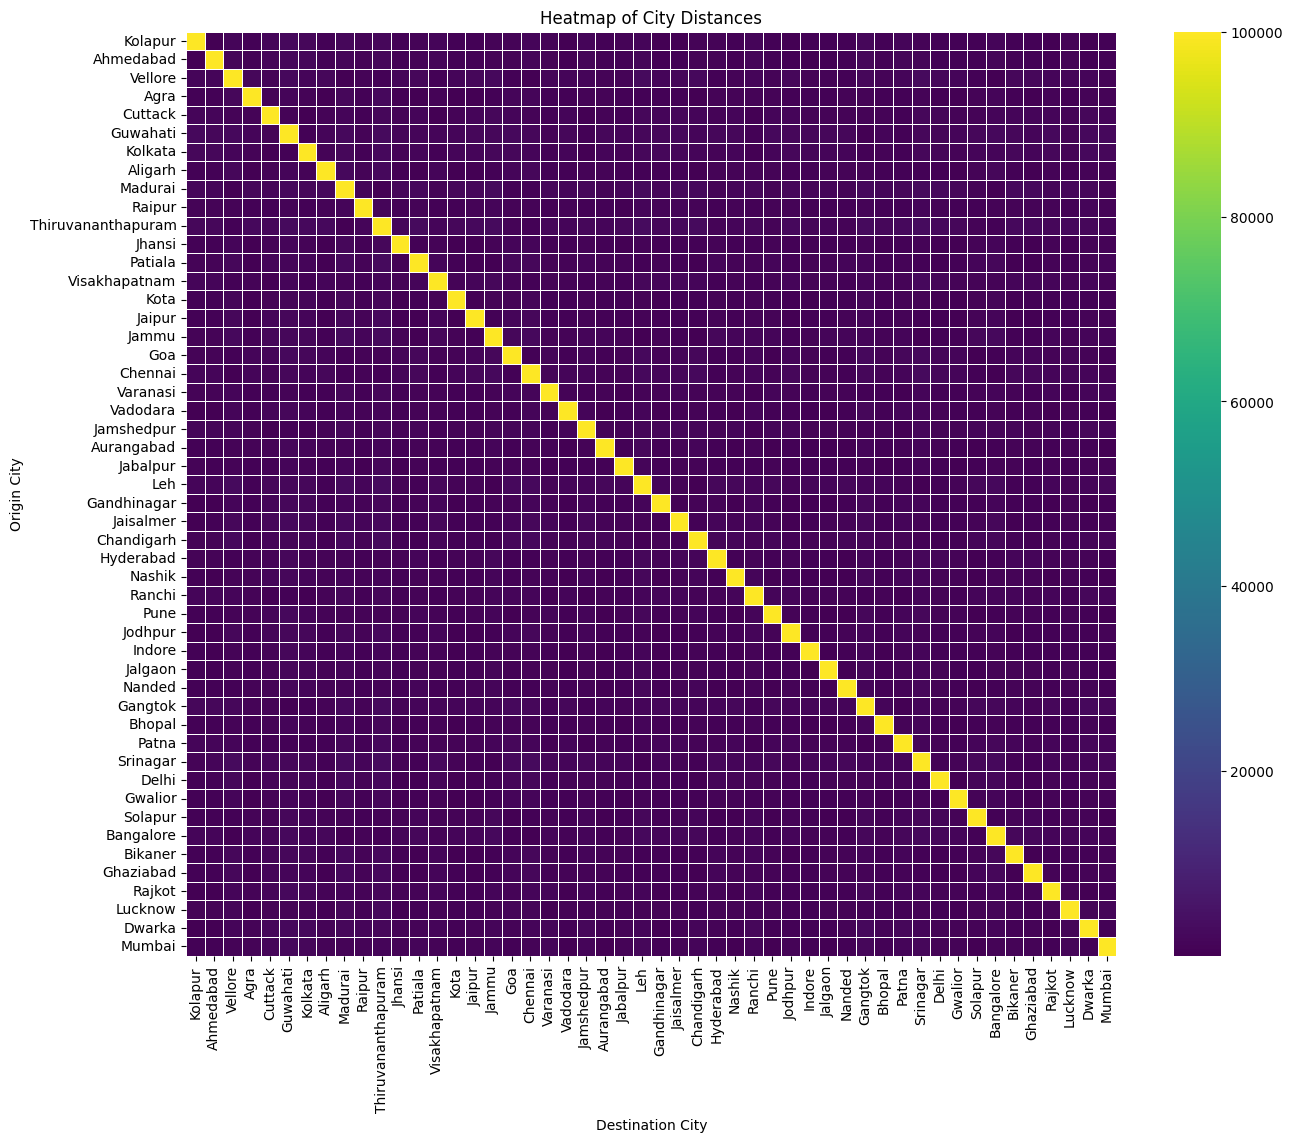

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 12))
sns.heatmap(df_distances, cmap='viridis', annot=False, fmt=".0f", linewidths=.5)
plt.title('Heatmap of City Distances')
plt.xlabel('Destination City')
plt.ylabel('Origin City')
plt.show()

In [ ]:
kolapur_entry = df[df['name'] == 'Kolapur']

if not kolapur_entry.empty:
    # Assuming df_locations also has 'state' column from the context
    # If not, adjust columns to match df_locations exactly
    if 'state' not in df_locations.columns:
        kolapur_entry = kolapur_entry[['id', 'name', 'latitude', 'longitude']]

    # Append the Kolapur entry to df_locations
    df_locations = pd.concat([df_locations, kolapur_entry], ignore_index=True)
    print("'Kolapur' added to df_locations. Displaying updated df_locations tail:")
    display(df_locations.tail())
else:
    print("'Kolapur' not found in the original 'df' DataFrame. Cannot add coordinates.")


'Kolapur' not found in the original 'df' DataFrame. Cannot add coordinates.


In [ ]:
import pandas as pd
import math
import heapq
import folium # Added folium import for visualization

graph = {}
cities = df_distances.index.tolist()

for city1 in cities:
    graph[city1] = {}
    for city2 in cities:
        if city1 != city2:
            distance = df_distances.loc[city1, city2]
            if pd.notna(distance): # Only add connection if distance is not NaN
                graph[city1][city2] = distance

# Redefine the heuristic function for the A* algorithm.
# Since we only have distances and no coordinates, we'll use a 'dummy' heuristic of 0.
# This effectively turns A* into Dijkstra's algorithm for shortest path finding.
def heuristic(a, b):
    return 0

# Re-defining A* search function for self-containment in this cell
def a_star_search(graph, start, goal):
    # Priority queue for nodes to visit
    frontier = []
    heapq.heappush(frontier, (0, start))

    came_from = {start: None}
    cost_so_far = {start: 0}

    while frontier:
        current_cost, current_node = heapq.heappop(frontier)

        if current_node == goal:
            break

        for next_node, distance in graph.get(current_node, {}).items():
            new_cost = cost_so_far[current_node] + distance
            if next_node not in cost_so_far or new_cost < cost_so_far[next_node]:
                cost_so_far[next_node] = new_cost
                priority = new_cost + heuristic(goal, next_node) # Using the redefined heuristic
                heapq.heappush(frontier, (priority, next_node))
                came_from[next_node] = current_node

    return came_from, cost_so_far

# Choose start and goal cities from the new dataset
start_city = 'Kolapur'
goal_city = 'Agra'

if start_city not in cities or goal_city not in cities:
    print(f"Error: Start city '{start_city}' or Goal city '{goal_city}' not found in the dataset.")
else:
    # Run A* search
    came_from, cost_so_far = a_star_search(graph, start_city, goal_city)

    # Reconstruct the path
    path = []
    current = goal_city
    while current is not None:
        path.append(current)
        current = came_from.get(current)
    path.reverse() # Path from start to goal

    if goal_city in cost_so_far:
        total_distance = cost_so_far[goal_city]
        print(f"Shortest path from {start_city} to {goal_city}:")
        print(" -> ".join(path))
        print(f"Total distance: {total_distance:.2f}")

        # --- Start of Visualization Code ---
        # df_locations is available in the kernel state.
        # Create a dictionary for quick lookup of city coordinates
        city_coords = df_locations.set_index('name')[['latitude', 'longitude']].apply(tuple, axis=1).to_dict()

        # Get coordinates for the path cities
        path_coords = []
        for city in path:
            if city in city_coords:
                path_coords.append(city_coords[city])
            else:
                print(f"Warning: Coordinates for {city} not found for visualization.")

        # Determine the map's center for better initial view
        if path_coords:
            avg_lat = sum([coord[0] for coord in path_coords]) / len(path_coords)
            avg_lon = sum([coord[1] for coord in path_coords]) / len(path_coords)
            map_center = [avg_lat, avg_lon]
        else:
            map_center = [23.0, 78.0] # Default center of India if no path coords

        m_path_viz = folium.Map(location=map_center, zoom_start=6)

        # Add markers for start and goal cities
        if start_city in city_coords:
            folium.Marker(city_coords[start_city], popup=f"Start: {start_city}", icon=folium.Icon(color='green')).add_to(m_path_viz)

        if goal_city in city_coords:
            folium.Marker(city_coords[goal_city], popup=f"Goal: {goal_city}", icon=folium.Icon(color='red')).add_to(m_path_viz)

        # Draw the path
        if len(path_coords) > 1:
            folium.PolyLine(path_coords, color='blue', weight=3, opacity=0.7).add_to(m_path_viz)

        print(f"Visualizing path from {start_city} to {goal_city}.")
        display(m_path_viz)
        # --- End of Visualization Code ---

    else:
        print(f"No path found from {start_city} to {goal_city}.")


Shortest path from Kolapur to Agra:
Kolapur -> Agra
Total distance: 737.24
Visualizing path from Kolapur to Agra.
